In [1]:
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.models import build_model
from modeling.split import make_split
from modeling.evaluate import _load_run
import pickle
from types import SimpleNamespace
from omegaconf import DictConfig, OmegaConf
from typing import Any
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from modeling.metrics import mae, rmse, poisson_deviance, relative_mae, relative_rmse

# Preprocess the files 

In [2]:
def get_model(filename: str):
    cfg = OmegaConf.create({'load_model': filename})
    model_path, run_cfg = _load_run(cfg)
    with open(model_path, "rb") as f:
        saved = pickle.load(f)
    model = saved["model"]
    feature_cols = saved["feature_cols"]
    feat_params = SimpleNamespace(**saved["feat_params"])
    return model, feature_cols, feat_params, run_cfg

In [3]:
def build_data(run_cfg: DictConfig, feat_params: Any):
    pothole_df, weather_df = build_daily(run_cfg)
    feat_df = assemble_features(pothole_df, weather_df, feat_params)
    feat_df = make_split(feat_df, run_cfg.split, feat_params)
    return feat_df



In [4]:
def _is_ts_mode(split_method: str) -> bool:
    return split_method in {"temporal", "temporal_window"}


def _predict_for_notebook(model, feat_df, test_df, X_test, run_cfg, naive_mode="strict"):
    """Use strict calendar behavior for naive baselines; keep recursive path for time-series models."""
    split_method = getattr(getattr(run_cfg, "split", None), "method", "random")

    if hasattr(model, "set_reference") and "date" in test_df.columns:
        if naive_mode not in {"strict", "oracle"}:
            raise ValueError(f"Unknown naive_mode: {naive_mode}")

        cutoff = None
        if naive_mode == "strict":
            test_start = pd.to_datetime(test_df["date"]).min().normalize()
            cutoff = test_start - pd.Timedelta(days=1)

        model.set_reference(feat_df[["date", "Y"]], max_actual_date=cutoff)
        return model.predict(test_df[["date"]], recursive=False)

    return model.predict(X_test, recursive=_is_ts_mode(split_method))


def get_results(f: str):
    model, feature_cols, feat_params, run_cfg = get_model(f)
    print(f"Feature params: {feat_params}")
    feat_df = build_data(run_cfg, feat_params)

    test_df = feat_df[feat_df["split"] == "test"]
    X_test = test_df[feature_cols]
    y_test = test_df["Y"]

    leakage = run_cfg.get("leakage", {}) if hasattr(run_cfg, "get") else {}
    naive_mode = str(leakage.get("naive_mode", "strict")) if leakage is not None else "strict"

    y_test_preds = _predict_for_notebook(
        model,
        feat_df,
        test_df,
        X_test,
        run_cfg,
        naive_mode=naive_mode,
    )

    return y_test, y_test_preds, test_df, model



## First Week 2025 (7-day daily forecast)

This section uses the fixed-date split (`split=first_week_2025`) and compares:
- negbin_glm
- poisson_glm
- naive_last_week
- naive_last_year
- xgb
- xgb_sarimax

Test window: `2025-01-01` to `2025-01-07` (7 rows).


FW2025 strict run dirs:
  negbin_glm       -> ward3_negbin_glm_fw2025_20200601_20251231_20260331_f6d9b4ff
  poisson_glm      -> ward3_poisson_glm_fw2025_20200601_20251231_20260331_7e1cf95f
  naive_last_week  -> ward3_naive_weekly_fw2025_20200601_20251231_20260331_54832a54
  naive_last_year  -> ward3_naive_yearly_fw2025_20200601_20251231_20260331_a2e8750e
  xgb              -> ward3_xgb_fw2025_20200601_20251231_20260331_0c1aa0f2
  xgb_sarimax      -> ward3_xgb_sarimax_fw2025_20200601_20251231_20260331_2622f323
Feature params: namespace(d=1, d_p=15, l_p=10, d_s=15, l_s=0, d_f=15, l_f=0, k_AR=0)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_p=15, l_p=10, d_s=15, l_s=0, d_f=15, l_f=0, k_AR=0)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_p=15, l_p=10, d_s=15, l_s=0, d_f=15, l_f=0, k_AR=0)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
[assemble_features] kept 1

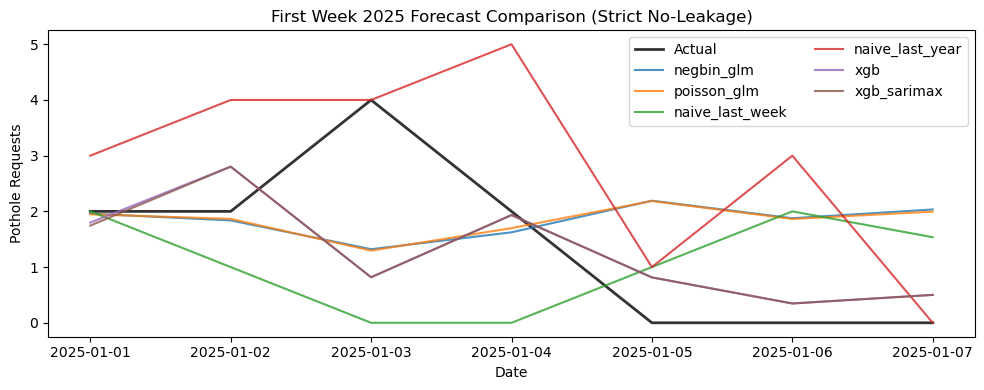

First-week-2025 metrics (sorted by MAE):


,Model,MAE,RMSE,Rel. MAE (%),Rel. RMSE (%),poisson_deviance,run_dir
0,xgb,0.845319,1.301279,0.332775,0.448792,1.420243,ward3_xgb_fw2025_20200601_20251231_20260331_0c...
1,xgb_sarimax,0.852741,1.302716,0.339578,0.450513,1.422413,ward3_xgb_sarimax_fw2025_20200601_20251231_202...
2,poisson_glm,1.319482,1.675739,0.229935,0.348166,2.251439,ward3_poisson_glm_fw2025_20200601_20251231_202...
3,negbin_glm,1.337360,1.682448,0.239784,0.350315,2.258344,ward3_negbin_glm_fw2025_20200601_20251231_2026...
4,naive_last_year,1.428571,1.851640,0.750000,0.935414,1.705770,ward3_naive_yearly_fw2025_20200601_20251231_20...
5,naive_last_week,1.647998,2.012789,0.625000,0.750000,33.250810,ward3_naive_weekly_fw2025_20200601_20251231_20...


Naive rule checks:


,Model,Exact matches
0,naive_last_week,6/7
1,naive_last_year,7/7


In [5]:
from pathlib import Path
import yaml

WEEK_START = pd.Timestamp("2025-01-01")
WEEK_END = pd.Timestamp("2025-01-07")

FW_PREFIX = {
    "negbin_glm": "ward3_negbin_glm_fw2025_",
    "poisson_glm": "ward3_poisson_glm_fw2025_",
    "naive_last_week": "ward3_naive_weekly_fw2025_",
    "naive_last_year": "ward3_naive_yearly_fw2025_",
    "xgb": "ward3_xgb_fw2025_",
    "xgb_sarimax": "ward3_xgb_sarimax_fw2025_",
}


def latest_stem_by_prefix(prefix: str, require_strict: bool = True) -> str:
    dirs = [d for d in Path("results").iterdir() if d.is_dir() and d.name.startswith(prefix)]
    if require_strict:
        filtered = []
        for d in dirs:
            run_cfg_path = d / "run.yaml"
            if not run_cfg_path.exists():
                continue
            try:
                run_data = yaml.safe_load(run_cfg_path.read_text())
            except Exception:
                continue
            leakage = run_data.get("leakage") or {}
            ok = bool(leakage.get("strict_no_leak", False)) and str(leakage.get("naive_mode", "")) == "strict"
            if ok:
                filtered.append(d)
        dirs = filtered

    if not dirs:
        raise FileNotFoundError(f"No run found for prefix: {prefix}")
    return sorted(dirs, key=lambda d: d.stat().st_mtime, reverse=True)[0].name


fw_runs = {}
missing_fw = []
for model_name, prefix in FW_PREFIX.items():
    try:
        fw_runs[model_name] = latest_stem_by_prefix(prefix, require_strict=True)
    except FileNotFoundError:
        missing_fw.append((model_name, prefix))

print("FW2025 strict run dirs:")
for k, v in fw_runs.items():
    print(f"  {k:16s} -> {v}")
if missing_fw:
    print("Missing strict runs for:")
    for model_name, prefix in missing_fw:
        print(f"  {model_name:16s} (prefix={prefix})")

plot_rows = []
metrics_rows = []
naive_checks = []
actual_week = None
dates_week = None

for model_key, stem in fw_runs.items():
    y_test, y_pred, test_df, model = get_results(stem)

    dates = pd.to_datetime(test_df["date"]).reset_index(drop=True)
    y_arr = np.asarray(y_test)
    p_arr = np.asarray(y_pred)

    mask = ((dates >= WEEK_START) & (dates <= WEEK_END)).to_numpy()
    dates_w = dates[mask]
    y_w = y_arr[mask]
    p_w = p_arr[mask]

    if len(y_w) != 7:
        raise ValueError(f"{model.name} has {len(y_w)} rows in first week 2025, expected 7")

    if actual_week is None:
        actual_week = y_w
        dates_week = dates_w

    plot_rows.append({
        "Model": model.name,
        "dates": dates_w,
        "pred": p_w,
    })

    metrics_rows.append({
        "Model": model.name,
        "MAE": mae(y_w, p_w),
        "RMSE": rmse(y_w, p_w),
        "Rel. MAE (%)": relative_mae(y_w, p_w),
        "Rel. RMSE (%)": relative_rmse(y_w, p_w),
        "poisson_deviance": poisson_deviance(y_w, p_w),
        "run_dir": stem,
    })

    if model.name in {"naive_last_week", "naive_last_year"}:
        feat_df = build_data(get_model(stem)[3], get_model(stem)[2])
        feat_df = feat_df.sort_values("date").reset_index(drop=True)
        feat_df["date"] = pd.to_datetime(feat_df["date"]).dt.normalize()
        y_map = dict(zip(feat_df["date"], feat_df["Y"]))

        exact = 0
        for dt, pred in zip(dates_w, p_w):
            dt = pd.Timestamp(dt).normalize()
            if model.name == "naive_last_week":
                ref = dt - pd.Timedelta(days=7)
            else:
                try:
                    ref = pd.Timestamp(year=dt.year - 1, month=dt.month, day=dt.day)
                except ValueError:
                    ref = pd.Timestamp(year=dt.year - 1, month=2, day=28)
            if abs(pred - y_map.get(ref, np.nan)) < 1e-9:
                exact += 1
        naive_checks.append({"Model": model.name, "Exact matches": f"{exact}/7"})



if not plot_rows:
    print("No strict FW2025 runs available. Please train strict runs first.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(dates_week, actual_week, label='Actual', color='black', linewidth=2, alpha=0.8)
    for row in plot_rows:
        ax.plot(row['dates'], row['pred'], label=row['Model'], alpha=0.8)

    ax.set_title('First Week 2025 Forecast Comparison (Strict No-Leakage)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Pothole Requests')
    ax.legend(loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame(metrics_rows).sort_values('MAE').reset_index(drop=True)
    print('First-week-2025 metrics (sorted by MAE):')
    display(metrics_df)

    if naive_checks:
        print('Naive rule checks:')
        display(pd.DataFrame(naive_checks))



# Plot over the models 

In [7]:
import matplotlib.colors as mcolors
import yaml
from pathlib import Path


def _is_strict_run(run_data: dict) -> bool:
    leakage = run_data.get("leakage") or {}
    return bool(leakage.get("strict_no_leak", False)) and str(leakage.get("naive_mode", "")) == "strict"


def latest_run_per_model_for_d(d: int, require_strict: bool = True):
    """Return one latest run directory per model for a given d."""
    candidates = [p for p in Path("results").iterdir() if p.is_dir() and f"d_{d}" in p.name]
    latest = {}

    for p in candidates:
        run_cfg_path = p / "run.yaml"
        if not run_cfg_path.exists():
            continue
        try:
            run_data = yaml.safe_load(run_cfg_path.read_text())
            model_name = run_data.get("model_name")
        except Exception:
            model_name = None
            run_data = {}
        if not model_name:
            continue

        if require_strict and not _is_strict_run(run_data):
            continue

        mtime = p.stat().st_mtime
        prev = latest.get(model_name)
        if prev is None or mtime > prev[0]:
            latest[model_name] = (mtime, p.name)

    return sorted(v[1] for v in latest.values())



Feature params: namespace(d=1, d_f=7, d_p=14, d_s=18, k_AR=0, l_f=1, l_p=1, l_s=8)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_f=7, d_p=14, d_s=18, k_AR=0, l_f=1, l_p=1, l_s=8)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_f=7, d_p=14, d_s=18, k_AR=0, l_f=1, l_p=1, l_s=8)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_f=7, d_p=19, d_s=20, k_AR=0, l_f=1, l_p=1, l_s=10)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=5, d_f=11, d_p=9, d_s=17, k_AR=0, l_f=10, l_p=6, l_s=9)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs
Feature params: namespace(d=5, d_f=11, d_p=9, d_s=17, k_AR=0, l_f=10, l_p=6, l_s=9)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs
Feature params: namespace(d=5, d_f=11, d_p=9, d_s=17, k_AR=0, l_f=10, l_p=6, l_s=9)
[assemb

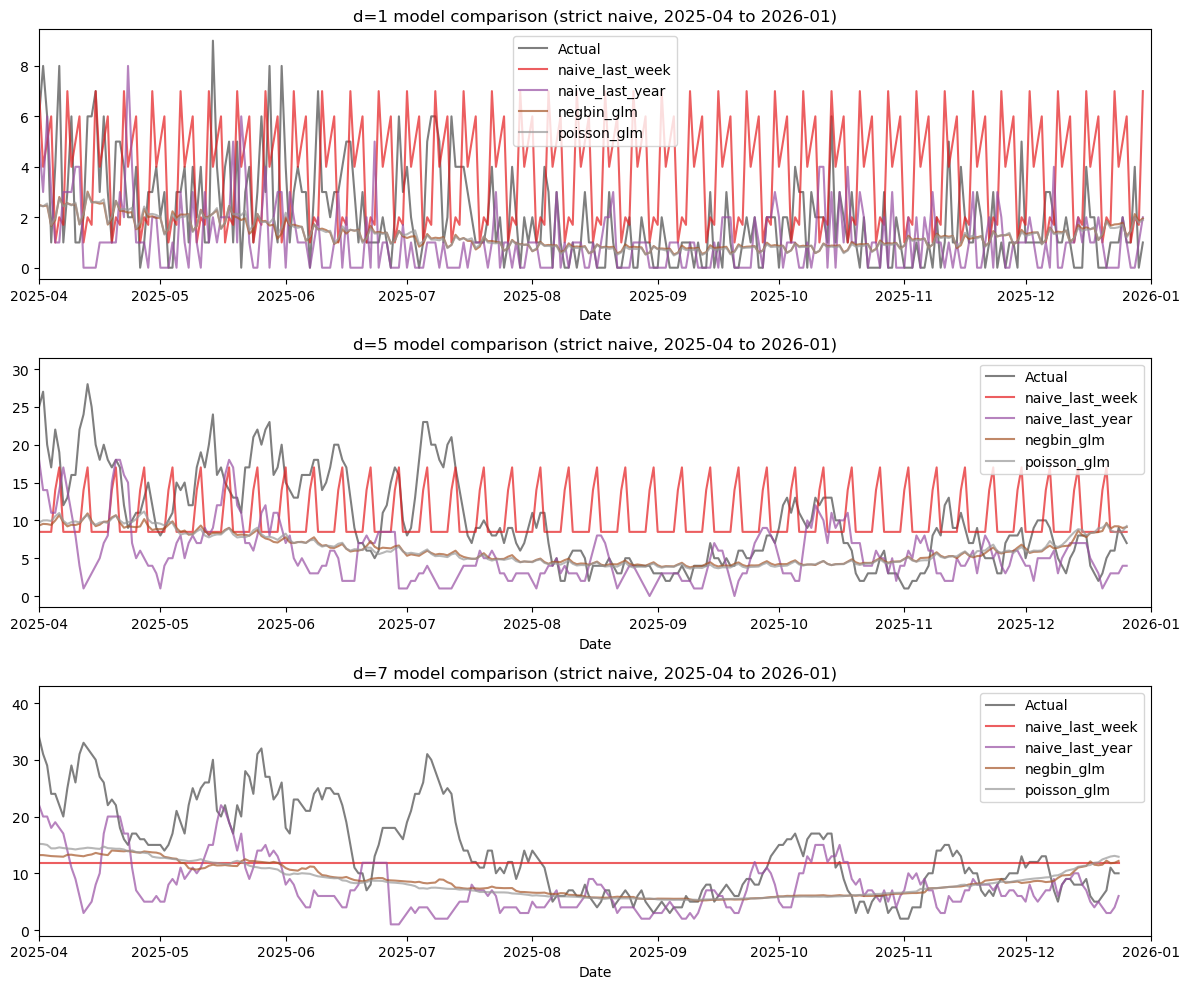

In [8]:
fig = plt.figure(figsize=(12, 10))
ax = fig.subplots(3, 1)
skipped_plot = []
plot_start = pd.Timestamp("2025-04-01")
plot_end = pd.Timestamp("2026-01-01")

for i, d in enumerate([1, 5, 7]):
    results = latest_run_per_model_for_d(d)

    cmap = plt.get_cmap("Set1")
    vals = np.linspace(0, 1, max(1, len(results)))
    colors = [mcolors.to_hex(cmap(v)) for v in vals]

    plotted = 0
    for f in results:
        try:
            y_test, y_test_preds, test_df, model = get_results(f)
        except Exception as e:
            skipped_plot.append((d, f, str(e).split("\n")[0]))
            continue

        dates = pd.to_datetime(test_df['date'])

        if plotted == 0:
            ax[i].plot(dates, y_test, label='Actual', alpha=0.5, color='black')

        ax[i].plot(
            dates,
            y_test_preds,
            label=f'{model.name}',
            alpha=0.7,
            color=colors[plotted % len(colors)],
        )
        plotted += 1

    ax[i].set_xlim(plot_start, plot_end)
    ax[i].set_xlabel('Date')
    ax[i].set_title(f'd={d} model comparison (strict naive, 2025-04 to 2026-01)')
    ax[i].legend()

plt.tight_layout()
plt.show()

if skipped_plot:
    print('\n[plot] skipped runs due to load/predict errors:')
    for d, f, msg in skipped_plot:
        print(f'  d={d}: {f} -> {msg}')


In [9]:
import pandas as pd
import numpy as np
test_errors = pd.DataFrame(columns=["d", "Model", "MAE", "RMSE", "Rel. MAE (%)", "Rel. RMSE (%)", "poisson_deviance", "correlation_coef", "run_dir"])
from modeling.metrics import mae, rmse, poisson_deviance, relative_mae, relative_rmse

skipped_metrics = []
for i, d in enumerate([1, 5, 7]):
    results = latest_run_per_model_for_d(d)

    for f in results:
        try:
            y_test, y_test_preds, test_df, model = get_results(f)
        except Exception as e:
            skipped_metrics.append((d, f, str(e).split("\n")[0]))
            continue

        test_errors.loc[len(test_errors)] = {
            "d": d,
            "Model": model.name,
            "MAE": mae(y_test, y_test_preds),
            "RMSE": rmse(y_test, y_test_preds),
            "Rel. MAE (%)": relative_mae(y_test, y_test_preds),
            "Rel. RMSE (%)": relative_rmse(y_test, y_test_preds),
            "poisson_deviance": poisson_deviance(y_test, y_test_preds),
            "correlation_coef": np.corrcoef(y_test, y_test_preds)[0, 1],
            "run_dir": f,
        }

print('rows per d:', test_errors.groupby('d').size().to_dict())
for d in [1, 5, 7]:
    models_d = sorted(test_errors[test_errors['d'] == d]['Model'].unique().tolist())
    print(f'd={d} models: {models_d}')

if skipped_metrics:
    print('\n[metrics] skipped runs due to load/predict errors:')
    for d, f, msg in skipped_metrics:
        print(f'  d={d}: {f} -> {msg}')


Feature params: namespace(d=1, d_f=7, d_p=14, d_s=18, k_AR=0, l_f=1, l_p=1, l_s=8)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_f=7, d_p=14, d_s=18, k_AR=0, l_f=1, l_p=1, l_s=8)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_f=7, d_p=14, d_s=18, k_AR=0, l_f=1, l_p=1, l_s=8)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_f=7, d_p=19, d_s=20, k_AR=0, l_f=1, l_p=1, l_s=10)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=5, d_f=11, d_p=9, d_s=17, k_AR=0, l_f=10, l_p=6, l_s=9)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs
Feature params: namespace(d=5, d_f=11, d_p=9, d_s=17, k_AR=0, l_f=10, l_p=6, l_s=9)
[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs
Feature params: namespace(d=5, d_f=11, d_p=9, d_s=17, k_AR=0, l_f=10, l_p=6, l_s=9)
[assemb

In [8]:
test_errors[test_errors['d'] == 1].sort_values('Rel. MAE (%)')

,d,Model,MAE,RMSE,Rel. MAE (%),Rel. RMSE (%),poisson_deviance,correlation_coef,run_dir
0,1,negbin_glm,1.352548,1.850012,0.488001,0.554243,1.828231,0.485908,ward3_best_glm_negbin_d_1_20200601_20251231_20...
1,1,poisson_glm,1.364055,1.876120,0.489687,0.556923,1.874722,0.447388,ward3_best_glm_poisson_d_1_20200601_20251231_2...
3,1,naive_last_year,1.737226,2.372285,0.796794,1.016313,29.672385,0.099701,ward3_naive_yearly_d_1_20200601_20251231_20260...
2,1,naive_last_week,1.667883,2.321747,0.848634,1.339331,11.977585,0.277845,ward3_naive_weekly_d_1_20200601_20251231_20260...


In [9]:
test_errors[test_errors['d'] == 5].sort_values('Rel. MAE (%)')

,d,Model,MAE,RMSE,Rel. MAE (%),Rel. RMSE (%),poisson_deviance,correlation_coef,run_dir
5,5,poisson_glm,4.836987,6.554257,0.474409,0.655900,4.453654,0.616409,ward3_best_glm_poisson_d_5_20200601_20251231_2...
4,5,negbin_glm,4.835301,6.556680,0.475180,0.657678,4.427293,0.628871,ward3_best_glm_negbin_d_5_20200601_20251231_20...
6,5,naive_last_week,4.003663,5.330471,0.532954,0.886789,2.628673,0.650998,ward3_naive_weekly_d_5_20200601_20251231_20260...
7,5,naive_last_year,5.597070,7.571878,0.560557,0.731779,12.521351,0.382489,ward3_naive_yearly_d_5_20200601_20251231_20260...


In [21]:
test_errors[test_errors['d'] == 7].sort_values('Rel. MAE (%)')

,d,Model,MAE,RMSE,Rel. MAE (%),Rel. RMSE (%),poisson_deviance,correlation_coef
8,7,negbin_glm,6.512635,8.730957,0.419351,0.513295,5.555772,0.695329
9,7,poisson_glm,6.572777,8.748589,0.428170,0.527343,5.767268,0.662918
10,7,xgb,6.590341,8.664350,0.450003,0.588442,5.953879,0.700542
11,7,xgb_sarimax,6.598944,8.604931,0.452962,0.566866,6.011066,0.670490


In [10]:
import tabulate
# Export results as markdown tables

for d in [1, 5, 7]:
    print(f"\n### Results for d={d}")
    subset = test_errors[test_errors['d'] == d].sort_values('Rel. MAE (%)')
    # Round numeric columns
    for col in ['MAE', 'RMSE', 'Rel. MAE (%)', 'Rel. RMSE (%)', 'poisson_deviance', 'correlation_coef']:
        subset[col] = subset[col].round(4)
    print(subset[['Model', 'MAE', 'RMSE', 'Rel. MAE (%)', 'Rel. RMSE (%)', 'poisson_deviance', 'correlation_coef']].to_markdown(index=False))


### Results for d=1
| Model           |    MAE |   RMSE |   Rel. MAE (%) |   Rel. RMSE (%) |   poisson_deviance |   correlation_coef |
|:----------------|-------:|-------:|---------------:|----------------:|-------------------:|-------------------:|
| negbin_glm      | 1.3526 | 1.8508 |         0.4872 |          0.5526 |             1.8289 |             0.4865 |
| poisson_glm     | 1.3505 | 1.8479 |         0.4915 |          0.5567 |             1.8284 |             0.4885 |
| naive_last_year | 1.731  | 2.3667 |         0.7941 |          1.0144 |            29.2698 |             0.1023 |
| naive_last_week | 2.7668 | 3.3551 |         1.5864 |          2.3802 |             3.579  |             0.0242 |

### Results for d=5
| Model           |    MAE |   RMSE |   Rel. MAE (%) |   Rel. RMSE (%) |   poisson_deviance |   correlation_coef |
|:----------------|-------:|-------:|---------------:|----------------:|-------------------:|-------------------:|
| poisson_glm     | 4.849  | 6.5742 | 